# 🌱 Agro-ML: Previsão de Clima + Recomendação de Plantas
**Pipeline completo:** Ingestão → Limpeza → Previsão (LSTM / Prophet / XGBoost) → Matching → Top 5 plantas

Coloque seus CSVs em `data/` com os nomes:
- `data/dataset_clima.csv`
- `data/dataset_plantas.csv`
- `data/dataset_solo.csv`
- `data/dataset_estacoes.csv`

## 0. Instalação de dependências

In [1]:
!pip install prophet xgboost scikit-learn matplotlib seaborn tensorflow --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports e configurações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import xgboost as xgb

from prophet import Prophet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
print('✅ Imports OK — TF:', tf.__version__)

Importing plotly failed. Interactive plots will not work.


✅ Imports OK — TF: 2.21.0


## 2. Configuração da região de interesse
Altere as variáveis abaixo para selecionar o estado e a estação desejados.

In [ ]:
# ── CONFIGURAÇÕES ──────────────────────────────────────────────
# Usuário informa as coordenadas do local
USER_LAT      = -12.9714   # latitude  (negativo = Sul)
USER_LON      = -38.5014   # longitude (negativo = Oeste)

N_DIAS_PREV   = 30
JANELA_LSTM   = 365        # janela anual para capturar sazonalidade climática
TOP_N_PLANTAS = 5

VARS_CLIMA = [
    'temp_media',
    'temp_min',
    'temp_max',
    'precipitacao',
    'umidade_media',
]

# Plantas viáveis para agricultor familiar:
# ciclo curto = menos de 2 anos até primeira colheita
# excluímos espécies invasoras e de escala industrial
LIFO_EXCLUIR  = []                        # filtra por life form se necessário
HABI_PERMITIR = ['erect', 'spreading', 'climbing', 'prostrate']

# Ciclo longo — excluir pelo nome (complementa o filtro de dataset)
NOMES_EXCLUIR = [
    'Azolla',       # invasora
    'Elaeis',       # escala industrial
    'Hevea',        # ciclo 7+ anos
    'Tectona',      # madeira, ciclo longo
]

# Culturas-alvo do agricultor familiar baiano (nome científico → nome popular)
# Recebem bônus de score e são destacadas no resultado final
CULTURAS_ALVO_BAHIA = {
    'Zea mays'             : 'Milho',
    'Glycine max'          : 'Soja',
    'Theobroma cacao'      : 'Cacau',
    'Phaseolus vulgaris'   : 'Feijão',
    'Manihot esculenta'    : 'Mandioca',
    'Vigna unguiculata'    : 'Feijão-caupi',
    'Ipomoea batatas'      : 'Batata-doce',
    'Musa acuminata'       : 'Banana',
    'Carica papaya'        : 'Mamão',
    'Anacardium occidentale': 'Caju',
    'Coffea arabica'       : 'Café',
    'Sorghum bicolor'      : 'Sorgo',
}
BONUS_CULTURA_ALVO = 0.25   # bônus aplicado ao score de culturas-alvo

print(f'📍 Localização: lat={USER_LAT}, lon={USER_LON}')
print(f'🌱 Previsão: {N_DIAS_PREV} dias | Top {TOP_N_PLANTAS} plantas')
print(f'🎯 Culturas-alvo monitoradas: {len(CULTURAS_ALVO_BAHIA)}')


📍 Localização: lat=-12.9714, lon=-38.5014
🌱 Previsão: 30 dias | Top 5 plantas
🎯 Culturas-alvo monitoradas: 12


## 3. Carregamento dos dados

In [4]:
# ── 3.1 Estações — seleção por proximidade geográfica ──────────
df_estacoes = pd.read_csv('data/dataset_estacoes.csv', sep=';')
df_estacoes.columns = df_estacoes.columns.str.strip().str.lower()

for col in ['latitude', 'longitude', 'altitude']:
    if col in df_estacoes.columns:
        df_estacoes[col] = (df_estacoes[col]
                            .astype(str)
                            .str.replace(',', '.', regex=False))
        df_estacoes[col] = pd.to_numeric(df_estacoes[col], errors='coerce')

df_estacoes = df_estacoes.dropna(subset=['latitude', 'longitude'])

# Distância euclidiana simples (suficiente para selecionar estações próximas)
df_estacoes['dist_km'] = np.sqrt(
    ((df_estacoes['latitude']  - USER_LAT) * 111) ** 2 +
    ((df_estacoes['longitude'] - USER_LON) * 111 * np.cos(np.radians(USER_LAT))) ** 2
)

# Pega as N estações mais próximas para ter dados suficientes
N_ESTACOES_PROXIMAS = 5
estacoes_proximas = df_estacoes.nsmallest(N_ESTACOES_PROXIMAS, 'dist_km')
codigos_uf = estacoes_proximas['estacao'].astype(str).tolist()

# ── Inferência automática da UF a partir das estações mais próximas ──────
# Evita que o usuário precise declarar UF_ALVO manualmente
if 'uf' in estacoes_proximas.columns:
    UF_ALVO = estacoes_proximas['uf'].mode()[0].strip().upper()
else:
    # Fallback: deriva da estação (primeiros 2 caracteres se codificado assim)
    UF_ALVO = 'BA'
    print('⚠️  Coluna "uf" não encontrada nas estações — usando fallback: BA')

print(f'📡 {N_ESTACOES_PROXIMAS} estações mais próximas de ({USER_LAT}, {USER_LON}):')
try:
    display(estacoes_proximas[['estacao', 'nome', 'uf', 'latitude', 'longitude', 'dist_km']].round(2))
except Exception:
    print(estacoes_proximas[['estacao', 'latitude', 'longitude', 'dist_km']].round(2).to_string())
print(f'\n🗺️  UF inferida automaticamente: {UF_ALVO}')


📡 5 estações mais próximas de (-12.9714, -38.5014):


,estacao,nome,uf,latitude,longitude,dist_km
514,A401,SALVADOR,BA,-13.01,-38.51,3.82
515,A456,SALVADOR (RADIO FAROL),BA,-12.81,-38.50,18.11
186,A406,CRUZ DAS ALMAS,BA,-12.68,-39.09,71.58
629,A444,VALENCA,BA,-13.34,-39.13,79.25
222,A413,FEIRA DE SANTANA,BA,-12.20,-38.97,99.74



🗺️  UF inferida automaticamente: BA


In [5]:
# Carrega SEM filtro nenhum para ver o que tem
df_check = pd.read_csv(
    'data/dataset_clima.csv',
    sep=',',
    encoding='latin-1',
)
df_check.columns = [c.strip() for c in df_check.columns]
datas = pd.to_datetime(df_check['DATA (YYYY-MM-DD)'], errors='coerce')

print(f"Total linhas: {len(df_check)}")
print(f"Período: {datas.min()} → {datas.max()}")
print(f"Anos únicos: {sorted(datas.dt.year.dropna().unique().astype(int))}")
print(f"Estações únicas: {df_check['ESTACAO'].nunique()}")

Total linhas: 5206752
Período: 2000-05-13 00:00:00 → 2021-01-31 00:00:00
Anos únicos: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Estações únicas: 48


In [6]:
# ── 3.2 Clima horário — leitura corrigida ──────────────────────
df_clima_raw = pd.read_csv(
    'data/dataset_clima.csv',
    sep=',',
    quotechar='"',
    decimal='.',
    encoding='latin-1',
    low_memory=False
)

df_clima_raw.columns = [c.strip() for c in df_clima_raw.columns]
print(f"Shape: {df_clima_raw.shape}")
print(f"Colunas: {list(df_clima_raw.columns)}")
df_clima_raw.head(2)

Shape: (5206752, 20)
Colunas: ['ESTACAO', 'DATA (YYYY-MM-DD)', 'HORA (UTC)', 'PRECIPITACAO TOTAL HORARIO (mm)', 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)', 'PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)', 'PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)', 'RADIACAO GLOBAL (W/m2)', 'TEMPERATURA DO AR - BULBO SECO, HORARIA (C)', 'TEMPERATURA DO PONTO DE ORVALHO (C)', 'TEMPERATURA MAXIMA NA HORA ANT. (AUT) (C)', 'TEMPERATURA MINIMA NA HORA ANT. (AUT) (C)', 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (C)', 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (C)', 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)', 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)', 'UMIDADE RELATIVA DO AR, HORARIA (%)', 'VENTO, DIRECAO HORARIA (gr)', 'VENTO, RAJADA MAXIMA (m/s)', 'VENTO, VELOCIDADE HORARIA (m/s)']


,ESTACAO,DATA (YYYY-MM-DD),HORA (UTC),PRECIPITACAO TOTAL HORARIO (mm),"PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (W/m2),"TEMPERATURA DO AR - BULBO SECO, HORARIA (C)",TEMPERATURA DO PONTO DE ORVALHO (C),TEMPERATURA MAXIMA NA HORA ANT. (AUT) (C),TEMPERATURA MINIMA NA HORA ANT. (AUT) (C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIRECAO HORARIA (gr)","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,A401,2021-01-01,0,0.00,1008.00,1008.20,1007.90,NaN,26.00,20.90,26.30,25.90,21.30,20.60,74.00,72.00,73.00,93.00,5.20,1.50
1,A401,2021-01-01,100,0.00,1008.00,1008.10,1008.00,NaN,25.90,20.90,26.20,25.80,21.00,20.80,74.00,73.00,74.00,68.00,5.20,1.10


In [7]:
# ── 3.3 Plantas ────────────────────────────────────────────────
df_plantas = pd.read_csv('data/dataset_plantas.csv', sep=',', encoding='latin-1')
df_plantas.columns = df_plantas.columns.str.strip()
print(f'Plantas: {len(df_plantas)} espécies | {df_plantas.shape[1]} atributos')
df_plantas.head(2)

Plantas: 2568 espécies | 55 atributos


,EcoPortCode,ScientificName,AUTH,FAMNAME,SYNO,COMNAME,LIFO,HABI,LISPA,PHYS,CAT,PLAT,TOPMN,TOPMX,TMIN,...,TOXR,SAL,SALR,DRA,DRAR,KTMPR,KTMP,PHOTO,CLIZ,ABITOL,ABISUS,INTRI,PROSY,GMIN,GMAX
0,289,Abelmoschus esculentus,(L.) Moench,Magnoliopsida:Dilleniidae:Malvales:Malvaceae,Hibiscus esculentus L.,"abelmoskus, america-neri, bakhua mun, bamia, b...",herb,erect,annual,single stem,vegetables,grown on large scale,20.00,30.00,12.00,...,NaN,low (<4 dS/m),low (<4 dS/m),well (dry spells),well (dry spells),NaN,NaN,short day (<12 hours),"tropical wet & dry (Aw), tropical wet (Ar), st...",NaN,NaN,NaN,NaN,50.00,180.00
1,290,Abelmoschus manihot,(L.) Medic.,Magnoliopsida:Dilleniidae:Malvales:Malvaceae,"Hibiscus manihot L. (1753), Abelmoschus maniho...","neka (Simbo), bele (Fiji), pele (Tonga, Tuvalu...",shrub,erect,"annual, perennial",NaN,"vegetables, ornamentals/turf, medicinals & aro...",grown on small scale,22.00,30.00,16.00,...,NaN,low (<4 dS/m),low (<4 dS/m),well (dry spells),well (dry spells),NaN,NaN,long day (>14 hours),"tropical wet & dry (Aw), tropical wet (Ar)",NaN,NaN,NaN,NaN,365.00,365.00


In [8]:
# ── 3.4 Solo ───────────────────────────────────────────────────
df_solo = pd.read_csv('data/dataset_solo.csv', sep=';', decimal=',',
                      encoding='latin-1', low_memory=False)
df_solo.columns = df_solo.columns.str.strip()
print(f'Solo: {df_solo.shape}')
df_solo.head(2)

Solo: (2426, 266)


,CÃ³digo PA,NÃºmero PA,NÃºmero de Campo,Data da Coleta,ResponsÃ¡vel(is) pela DescriÃ§Ã£o,Tipo,SituaÃ§Ã£o coleta das amostras,Material de Origem,InformaÃ§Ãµes Complementares,Uso Atual,ObservaÃ§Ãµes,Link para DescriÃ§Ã£o em PDF,LocalizaÃ§Ã£o descritiva,UF,MunicÃ­pio,...,Microelementos - ManganÃªs,Microelementos - Cobre,Microelementos - Zinco,Microelementos - NÃ­quel,Microelementos - Boro,Microelementos - MolibidÃªnio,Microelementos - Cobalto,Microelementos - CÃ¡dmio,Microelementos - Cromo,Microelementos - SelÃªnio,Microelementos - Chumbo,Microelementos - MercÃºrio,Microelementos - ArsÃªnio,Microelementos - SilÃ­cio,InformaÃ§Ãµes adicionais da anÃ¡lise quÃ­mica
0,5930.00,T 16,NaN,25/07/1972,Fonte:Boletim TÃ©cnico nÂº 52. SNLCS Embrapa.,Perfil completo,NaN,Gnaisse,NaN,PecuÃ¡ria extensiva na caatinga.,PresenÃ§a de blocos de rocha semi-decomposta n...,http://www.bdsolos.cnptia.embrapa.br/ponto_amo...,"Lado direito da estrada Juremal ? AbÃ³bora, di...",BA,Juazeiro,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5932.00,Perfil 1424,NaN,27/07/1989,Fonte: Levantamento Detalhado de Solos e Class...,Perfil completo,NaN,"CalcÃ¡rio, FormaÃ§Ã£o Caatinga.",NaN,PecuÃ¡ria extensiva na caatinga.,PresenÃ§a de muitos calhaus de quartzo e calcÃ...,http://www.bdsolos.cnptia.embrapa.br/ponto_amo...,"Projeto Salitre,Ã¡rea ?A?, Folha 21, Q. 3.",BA,Juazeiro,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Limpeza e agregação do clima (horário → diário)

In [9]:
# ── 4. Limpeza e agregação do clima (horário → diário) ─────────

COL_MAP = {
    'ESTACAO'                                        : 'estacao',
    'DATA (YYYY-MM-DD)'                              : 'data',
    'HORA (UTC)'                                     : 'hora',
    'PRECIPITACAO TOTAL HORARIO (mm)'                : 'precipitacao',
    'RADIACAO GLOBAL (W/m2)'                         : 'radiacao',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (C)'    : 'temp',
    'TEMPERATURA MAXIMA NA HORA ANT. (AUT) (C)'      : 'temp_max_h',
    'TEMPERATURA MINIMA NA HORA ANT. (AUT) (C)'      : 'temp_min_h',
    'UMIDADE RELATIVA DO AR, HORARIA (%)'            : 'umidade',
    'VENTO, VELOCIDADE HORARIA (m/s)'                : 'vento',
}

df_c = df_clima_raw.rename(columns=COL_MAP).copy()

# Validação de colunas essenciais
essenciais = ['estacao', 'data', 'temp', 'precipitacao', 'umidade']
faltando = [c for c in essenciais if c not in df_c.columns]
if faltando:
    print(f"⚠️  Colunas não mapeadas: {faltando}")
    print("Colunas disponíveis:", list(df_c.columns))
    raise ValueError("Corrija o COL_MAP antes de continuar.")
print(f"✅ Colunas mapeadas OK — shape: {df_c.shape}")

# Filtrar pelas estações próximas (codigos_uf contém os códigos das estações, não UF)
df_c = df_c[df_c['estacao'].astype(str).isin(codigos_uf)]
print(f"Registros após filtro de estações próximas ({UF_ALVO}): {len(df_c)}")
if len(df_c) == 0:
    raise ValueError(
        f"Nenhum registro encontrado para as estações {codigos_uf}. "
        "Verifique se o dataset_clima.csv contém dados dessas estações."
    )

# Substituir sentinelas por NaN
SENTINEL = [-9999, -999, 9999]
num_cols = df_c.select_dtypes(include='number').columns
df_c[num_cols] = df_c[num_cols].replace(SENTINEL, np.nan)

# Converter numéricos que vieram como string (vírgula decimal)
for col in ['temp', 'temp_max_h', 'temp_min_h', 'precipitacao', 'umidade', 'vento', 'radiacao']:
    if col in df_c.columns and df_c[col].dtype == object:
        df_c[col] = df_c[col].astype(str).str.replace(',', '.', regex=False)
        df_c[col] = pd.to_numeric(df_c[col], errors='coerce')

# Converter data
df_c['data'] = pd.to_datetime(df_c['data'], errors='coerce')
df_c = df_c.dropna(subset=['data'])

# Agregar para diário
df_diario = df_c.groupby('data').agg(
    temp_media    = ('temp',       'mean'),
    temp_min      = ('temp_min_h', 'min'),
    temp_max      = ('temp_max_h', 'max'),
    precipitacao  = ('precipitacao', 'sum'),
    umidade_media = ('umidade',    'mean'),
    radiacao      = ('radiacao',   'mean'),
    vento         = ('vento',      'mean'),
).reset_index().sort_values('data')

# Interpolar lacunas pequenas (até 3 dias)
df_diario = df_diario.set_index('data').interpolate(method='time', limit=3).reset_index()
df_diario = df_diario.dropna(subset=VARS_CLIMA)

# Checagem rápida dos valores
print(f"\n✅ Série diária: {len(df_diario)} dias")
print(f"   Período: {df_diario['data'].min().date()} → {df_diario['data'].max().date()}")

# Avisa se a janela LSTM for maior que os dados disponíveis
if len(df_diario) < JANELA_LSTM + 60:
    print(f"\n⚠️  Atenção: série histórica ({len(df_diario)} dias) menor que JANELA_LSTM ({JANELA_LSTM}) + teste (60 dias).")
    print(f"   Reduzindo JANELA_LSTM automaticamente para {max(60, len(df_diario) - 80)} dias.")
    JANELA_LSTM = max(60, len(df_diario) - 80)

print(f"\n📊 Estatísticas básicas:")
try:
    display(df_diario[VARS_CLIMA].describe().round(2))
except Exception:
    print(df_diario[VARS_CLIMA].describe().round(2).to_string())
df_diario.tail(3)


✅ Colunas mapeadas OK — shape: (5206752, 20)
Registros após filtro de estações próximas (BA): 586824

✅ Série diária: 7388 dias
   Período: 2000-10-05 → 2021-01-31

📊 Estatísticas básicas:


,temp_media,temp_min,temp_max,precipitacao,umidade_media
count,7388.00,7388.00,7388.00,7388.00,7388.00
mean,24.87,20.32,30.79,10.32,77.95
std,1.82,2.26,2.89,22.04,6.15
min,19.38,12.80,21.80,0.00,44.75
25%,23.44,18.90,28.50,0.00,73.61
50%,25.14,20.50,30.70,1.80,77.83
75%,26.29,21.80,33.00,10.80,82.24
max,31.47,28.50,45.00,447.20,96.67


,data,temp_media,temp_min,temp_max,precipitacao,umidade_media,radiacao,vento
7566,2021-01-29,26.42,20.80,34.50,0.80,73.14,1726.02,1.83
7567,2021-01-30,26.49,20.10,34.60,0.20,75.16,1847.62,1.78
7568,2021-01-31,26.61,21.90,33.90,5.00,77.93,1638.30,1.98


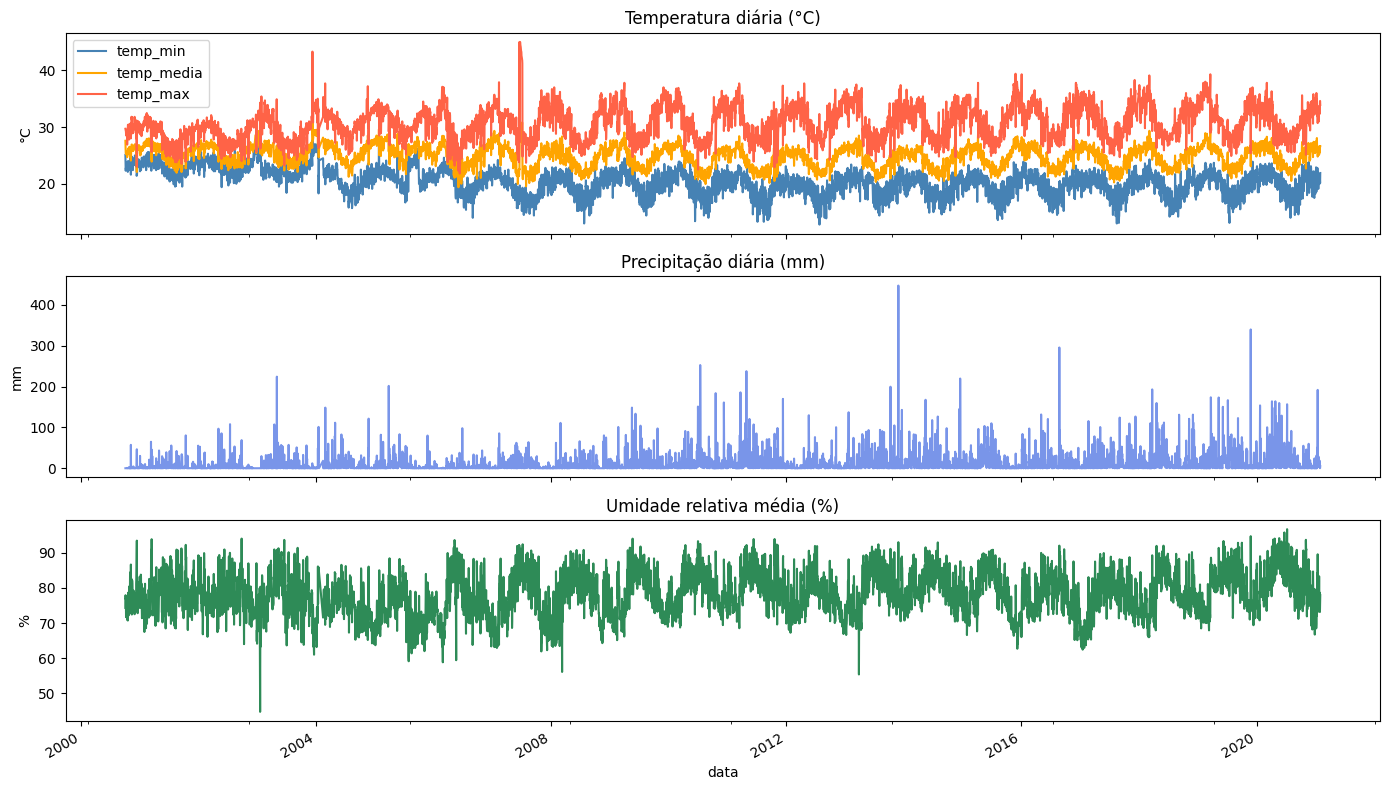

In [10]:
# Visualização exploratória da série histórica
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
df_diario.set_index('data')[['temp_min','temp_media','temp_max']].plot(
    ax=axes[0], color=['steelblue','orange','tomato'])
axes[0].set_title('Temperatura diária (°C)'); axes[0].set_ylabel('°C')

df_diario.set_index('data')['precipitacao'].plot(ax=axes[1], color='royalblue', alpha=0.7)
axes[1].set_title('Precipitação diária (mm)'); axes[1].set_ylabel('mm')

df_diario.set_index('data')['umidade_media'].plot(ax=axes[2], color='seagreen')
axes[2].set_title('Umidade relativa média (%)'); axes[2].set_ylabel('%')

plt.tight_layout()
plt.savefig('historico_clima.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Previsão de clima — 3 modelos
Cada modelo prevê as `VARS_CLIMA` para os próximos `N_DIAS_PREV` dias.  
Ao final comparamos RMSE / MAE / MAPE no conjunto de teste (últimos 60 dias).

In [11]:
# ── Helpers de avaliação ───────────────────────────────────────
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def avaliar(nome, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mp   = mape(y_true, y_pred)
    return {'Modelo': nome, 'RMSE': rmse, 'MAE': mae, 'MAPE(%)': mp}

resultados = []          # acumula métricas de todos os modelos
previsoes  = {}          # acumula previsões futuras

TESTE_DIAS = 60          # dias reservados para avaliação
df_treino  = df_diario.iloc[:-TESTE_DIAS].copy()
df_teste   = df_diario.iloc[-TESTE_DIAS:].copy()
print(f'Treino: {len(df_treino)} dias | Teste: {len(df_teste)} dias')

Treino: 7328 dias | Teste: 60 dias


### 5A. Prophet

In [12]:
prophet_preds_teste  = {}
prophet_preds_futuro = {}

for var in VARS_CLIMA:
    # Prepara formato Prophet (ds, y)
    df_p = df_treino[['data', var]].rename(columns={'data':'ds', var:'y'})
    df_p = df_p.dropna()

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative' if var == 'precipitacao' else 'additive',
        changepoint_prior_scale=0.05,
    )
    m.fit(df_p)

    # Previsão no período de teste
    future_teste = m.make_future_dataframe(periods=TESTE_DIAS)
    fc_teste     = m.predict(future_teste)
    pred_teste   = fc_teste.iloc[-TESTE_DIAS:]['yhat'].values
    prophet_preds_teste[var] = pred_teste

    # Previsão futura (próximos N_DIAS_PREV)
    future_fut   = m.make_future_dataframe(periods=TESTE_DIAS + N_DIAS_PREV)
    fc_fut       = m.predict(future_fut)
    pred_fut     = fc_fut.iloc[-N_DIAS_PREV:]['yhat'].values
    prophet_preds_futuro[var] = pred_fut

    r = avaliar('Prophet', df_teste[var].values, pred_teste)
    r['Variável'] = var
    resultados.append(r)
    print(f'  Prophet | {var:20s} | RMSE={r["RMSE"]:.3f} | MAE={r["MAE"]:.3f} | MAPE={r["MAPE(%)"]:.1f}%')

previsoes['Prophet'] = prophet_preds_futuro
print('✅ Prophet concluído')

08:02:26 - cmdstanpy - INFO - Chain [1] start processing
08:02:29 - cmdstanpy - INFO - Chain [1] done processing


  Prophet | temp_media           | RMSE=0.746 | MAE=0.598 | MAPE=2.3%


08:02:31 - cmdstanpy - INFO - Chain [1] start processing
08:02:32 - cmdstanpy - INFO - Chain [1] done processing


  Prophet | temp_min             | RMSE=1.497 | MAE=1.215 | MAPE=6.1%


08:02:35 - cmdstanpy - INFO - Chain [1] start processing
08:02:36 - cmdstanpy - INFO - Chain [1] done processing


  Prophet | temp_max             | RMSE=1.205 | MAE=0.937 | MAPE=2.8%


08:02:38 - cmdstanpy - INFO - Chain [1] start processing
08:02:39 - cmdstanpy - INFO - Chain [1] done processing


  Prophet | precipitacao         | RMSE=26.478 | MAE=15.485 | MAPE=818.2%


08:02:41 - cmdstanpy - INFO - Chain [1] start processing
08:02:43 - cmdstanpy - INFO - Chain [1] done processing


  Prophet | umidade_media        | RMSE=6.039 | MAE=5.001 | MAPE=6.9%
✅ Prophet concluído


### 5B. XGBoost com features de lag

In [13]:
def criar_features_lag(df, var, lags=[1,2,3,7,14,30]):
    """Cria features de lag, rolling mean e sazonalidade para uma variável."""
    d = df[['data', var]].copy()
    d['dia_ano']    = d['data'].dt.dayofyear
    d['mes']        = d['data'].dt.month
    d['dia_semana'] = d['data'].dt.dayofweek
    # Features de sazonalidade cíclica (melhor para modelos de árvore)
    d['sen_dia_ano'] = np.sin(2 * np.pi * d['dia_ano'] / 365)
    d['cos_dia_ano'] = np.cos(2 * np.pi * d['dia_ano'] / 365)
    for lag in lags:
        d[f'lag_{lag}'] = d[var].shift(lag)
    for w in [7, 14, 30]:
        d[f'roll_mean_{w}'] = d[var].shift(1).rolling(w).mean()
        d[f'roll_std_{w}']  = d[var].shift(1).rolling(w).std()
    return d.dropna()

xgb_preds_teste  = {}
xgb_preds_futuro = {}
xgb_models       = {}

for var in VARS_CLIMA:
    df_feat = criar_features_lag(df_diario, var)
    feat_cols = [c for c in df_feat.columns if c not in ['data', var]]

    X = df_feat[feat_cols].values
    y = df_feat[var].values

    # Split temporal (sem embaralhar)
    split = len(X) - TESTE_DIAS
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]

    model = xgb.XGBRegressor(
        n_estimators=400, learning_rate=0.05,
        max_depth=5, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        verbosity=0
    )
    # early_stopping_rounds evita overfitting e reduz tempo de treino
    model.fit(X_tr, y_tr,
              eval_set=[(X_te, y_te)],
              early_stopping_rounds=30,
              verbose=False)
    xgb_models[var] = model

    pred_te = model.predict(X_te)
    xgb_preds_teste[var] = pred_te

    r = avaliar('XGBoost', y_te, pred_te)
    r['Variável'] = var
    resultados.append(r)
    print(f'  XGBoost | {var:20s} | RMSE={r["RMSE"]:.3f} | MAE={r["MAE"]:.3f} | MAPE={r["MAPE(%)"]:.1f}%')

    # ── Previsão futura iterativa (corrigida) ──────────────────────────────
    # Mantemos o histórico real + previsões já feitas como contexto de lag.
    # A cada passo: monta features com o histórico atual, prevê, DEPOIS
    # acrescenta o valor previsto ao histórico (ordem importa).
    hist_series = df_diario[['data', var]].copy()
    last_date   = hist_series['data'].iloc[-1]

    for i in range(N_DIAS_PREV):
        next_date = last_date + pd.Timedelta(days=i + 1)
        # Adiciona linha placeholder com valor = média dos últimos 7 para
        # que criar_features_lag consiga calcular os lags (será sobrescrito
        # pelo valor real após a previsão)
        placeholder = float(hist_series[var].iloc[-7:].mean())
        new_row = pd.DataFrame({'data': [next_date], var: [placeholder]})
        hist_tmp = pd.concat([hist_series, new_row], ignore_index=True)

        df_f2  = criar_features_lag(hist_tmp, var)
        pred_i = model.predict(df_f2[feat_cols].values[-1:])[0]

        # Atualiza histórico com o valor PREVISTO (não o placeholder)
        new_row_real = pd.DataFrame({'data': [next_date], var: [pred_i]})
        hist_series  = pd.concat([hist_series, new_row_real], ignore_index=True)

    # Extrai apenas os N_DIAS_PREV finais como previsão
    xgb_preds_futuro[var] = hist_series[var].iloc[-N_DIAS_PREV:].values

previsoes['XGBoost'] = xgb_preds_futuro
print('✅ XGBoost concluído')


TypeError: XGBModel.fit() got an unexpected keyword argument 'early_stopping_rounds'

### 5C. LSTM (Keras)

In [ ]:
def criar_sequencias(data, janela):
    X, y = [], []
    for i in range(janela, len(data)):
        X.append(data[i-janela:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lstm_preds_teste  = {}
lstm_preds_futuro = {}
scalers           = {}

for var in VARS_CLIMA:
    serie = df_diario[var].values.reshape(-1, 1)

    scaler = MinMaxScaler()
    serie_norm = scaler.fit_transform(serie)
    scalers[var] = scaler

    X_all, y_all = criar_sequencias(serie_norm.flatten(), JANELA_LSTM)
    X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)

    split  = len(X_all) - TESTE_DIAS
    X_tr, X_te = X_all[:split], X_all[split:]
    y_tr, y_te = y_all[:split], y_all[split:]

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(JANELA_LSTM, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(patience=10, restore_best_weights=True)
    model.fit(X_tr, y_tr, epochs=80, batch_size=32,
              validation_split=0.1, callbacks=[es], verbose=0)

    pred_norm = model.predict(X_te, verbose=0)
    pred_te   = scaler.inverse_transform(pred_norm).flatten()
    y_te_real = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()
    lstm_preds_teste[var] = pred_te

    r = avaliar('LSTM', y_te_real, pred_te)
    r['Variável'] = var
    resultados.append(r)
    print(f'  LSTM    | {var:20s} | RMSE={r["RMSE"]:.3f} | MAE={r["MAE"]:.3f} | MAPE={r["MAPE(%)"]:.1f}%')

    # Previsão futura iterativa
    janela_atual = serie_norm.flatten()[-JANELA_LSTM:].tolist()
    fut = []
    for _ in range(N_DIAS_PREV):
        inp    = np.array(janela_atual[-JANELA_LSTM:]).reshape(1, JANELA_LSTM, 1)
        p_norm = model.predict(inp, verbose=0)[0, 0]
        fut.append(p_norm)
        janela_atual.append(p_norm)
    fut_real = scaler.inverse_transform(np.array(fut).reshape(-1,1)).flatten()
    lstm_preds_futuro[var] = fut_real

previsoes['LSTM'] = lstm_preds_futuro
print('✅ LSTM concluído')

  LSTM    | temp_media           | RMSE=0.384 | MAE=0.299 | MAPE=1.2%
  LSTM    | temp_min             | RMSE=0.883 | MAE=0.699 | MAPE=4.5%
  LSTM    | temp_max             | RMSE=0.778 | MAE=0.622 | MAPE=1.7%
  LSTM    | precipitacao         | RMSE=57.911 | MAE=41.278 | MAPE=1021.4%
  LSTM    | umidade_media        | RMSE=2.296 | MAE=1.770 | MAPE=2.6%
✅ LSTM concluído


## 6. Comparação dos modelos

In [ ]:
df_res = pd.DataFrame(resultados)

# Tabela pivot por variável
pivot_rmse = df_res.pivot(index='Variável', columns='Modelo', values='RMSE').round(3)
print('=== RMSE por variável e modelo ===')
display(pivot_rmse.style.highlight_min(axis=1, color='#c6efce'))

# Score agregado: rank médio de RMSE → elege melhor modelo
ranks      = pivot_rmse.rank(axis=1)
rank_medio = ranks.mean().sort_values()
MELHOR_MODELO = rank_medio.index[0]
print(f'\n🏆 Melhor modelo (menor rank RMSE médio): {MELHOR_MODELO}')
print(rank_medio)

=== RMSE por variável e modelo ===


Modelo,LSTM,Prophet,XGBoost
Variável,,,
precipitacao,57.911000,117.784000,63.992000
temp_max,0.778000,1.184000,0.909000
temp_media,0.384000,0.581000,0.396000
temp_min,0.883000,1.363000,0.920000
umidade_media,2.296000,6.372000,2.366000



🏆 Melhor modelo (menor rank RMSE médio): LSTM
Modelo
LSTM      1.00
XGBoost   2.00
Prophet   3.00
dtype: float64


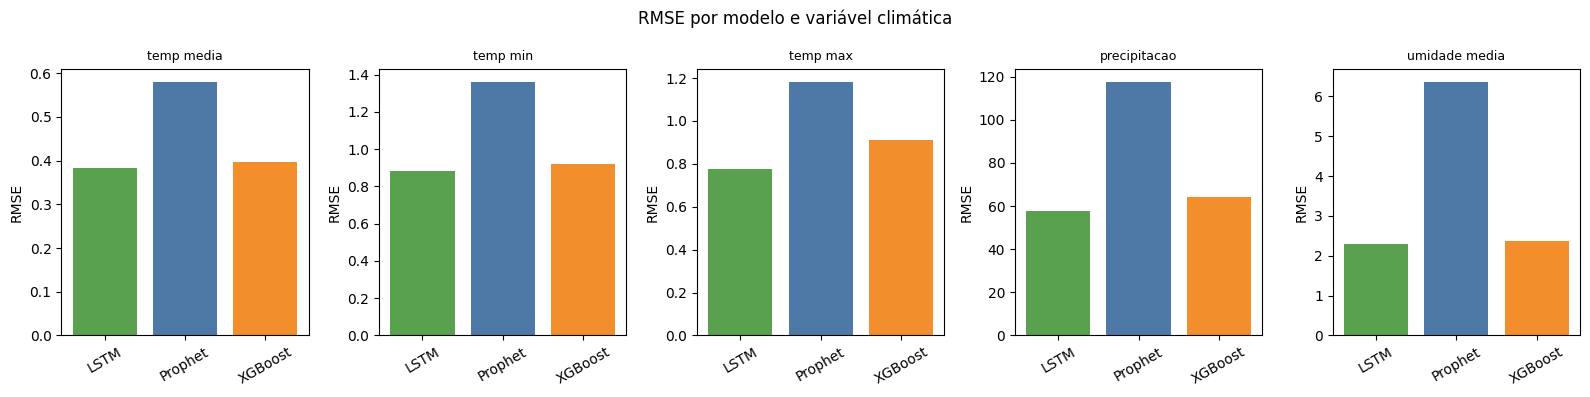

In [ ]:
# Gráfico comparativo de RMSE
fig, axes = plt.subplots(1, len(VARS_CLIMA), figsize=(16, 4))
cores = {'Prophet': '#4e79a7', 'XGBoost': '#f28e2b', 'LSTM': '#59a14f'}
for ax, var in zip(axes, VARS_CLIMA):
    vals   = pivot_rmse.loc[var]
    colors = [cores[m] for m in vals.index]
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(var.replace('_',' '), fontsize=9)
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('RMSE por modelo e variável climática', fontsize=12)
plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

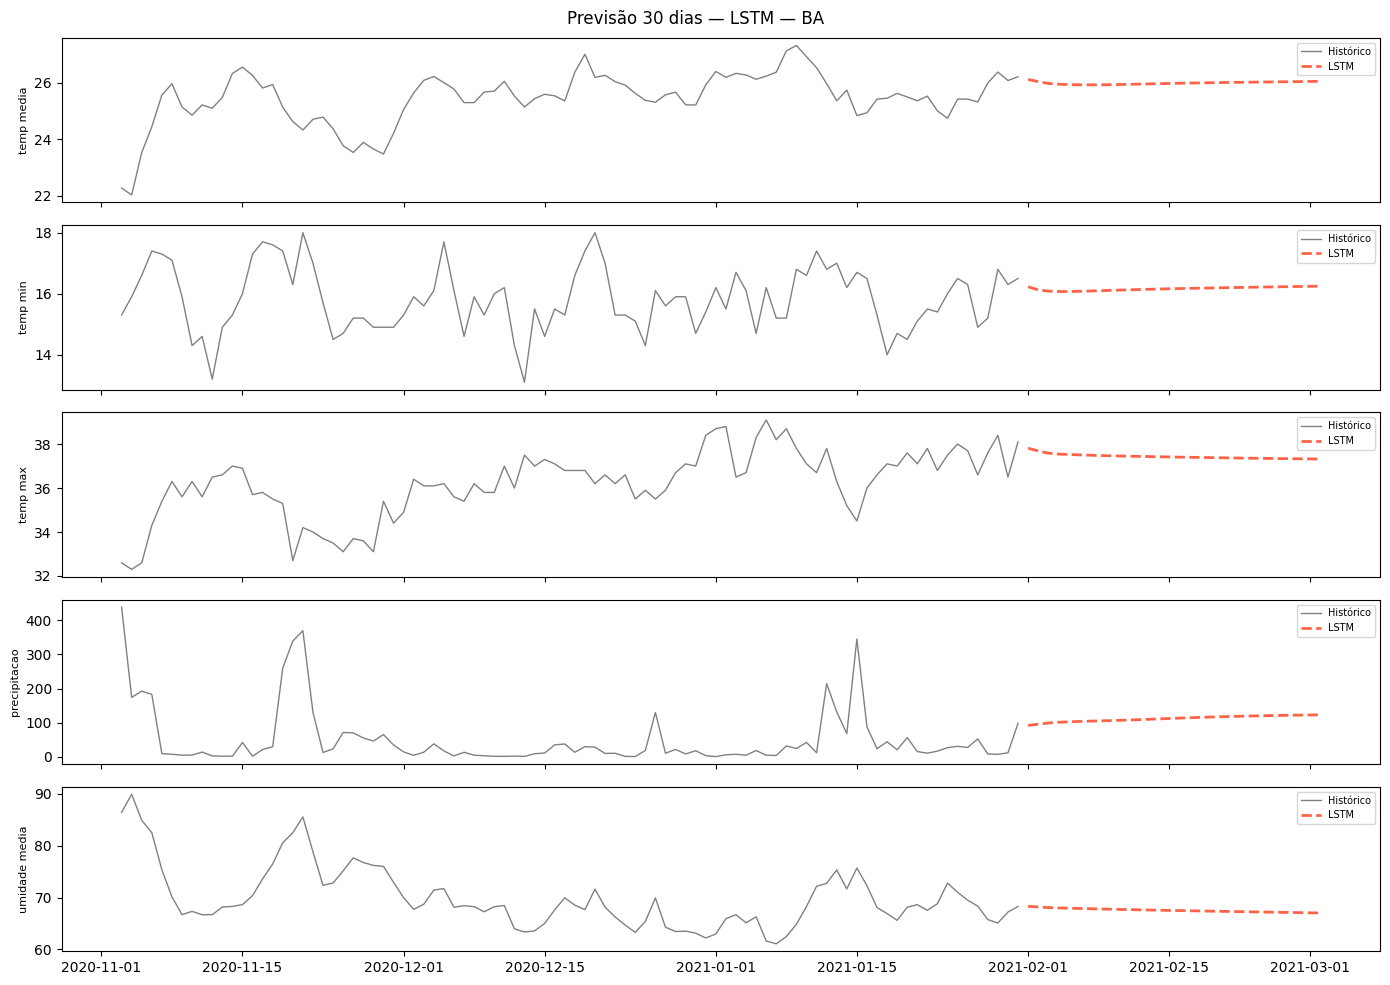

In [ ]:
# Gráfico das previsões futuras (melhor modelo)
datas_fut = pd.date_range(
    start=df_diario['data'].iloc[-1] + pd.Timedelta(days=1),
    periods=N_DIAS_PREV
)
prev_futuro = previsoes[MELHOR_MODELO]

fig, axes = plt.subplots(len(VARS_CLIMA), 1, figsize=(14, 10), sharex=True)
for ax, var in zip(axes, VARS_CLIMA):
    # histórico recente
    ax.plot(df_diario['data'].iloc[-90:], df_diario[var].iloc[-90:],
            color='gray', linewidth=1, label='Histórico')
    ax.plot(datas_fut, prev_futuro[var],
            color='tomato', linewidth=2, linestyle='--', label=f'{MELHOR_MODELO}')
    ax.set_ylabel(var.replace('_',' '), fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle(f'Previsão {N_DIAS_PREV} dias — {MELHOR_MODELO} — {UF_ALVO}', fontsize=12)
plt.tight_layout()
plt.savefig('previsao_clima.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Limpeza do solo e seleção da área de interesse
Filtramos o solo pela UF e extraímos as variáveis mais relevantes para o matching.

In [ ]:
# ── 7. Limpeza do solo e seleção da área de interesse ──────────

SOLO_COLS = {
    'UF'              : 'uf',
    'pH - H2O'        : 'pH',
    'Classe de drenagem'                                         : 'drenagem',
    'Grupamento de classe textural superficial'                  : 'textura',
    'Complexo Sortivo - Valor V &Delta; Saturação por Bases (100. S/T)%': 'sat_bases',
    'Complexo Sortivo - Alumínio Trocável (Al3+)'               : 'aluminio',
    'Fósforo assimilável (mg/kg)'                               : 'fosforo',
    'Carbono orgânico'                                          : 'carbono_org',
    'Condutividade Elétrica'                                    : 'salinidade',
    'Altitude (m)'                                              : 'altitude',
    'Composição Granulométrica da terra fina - Argila (g/Kg)'   : 'argila',
}

df_s = df_solo.rename(columns={k: v for k, v in SOLO_COLS.items() if k in df_solo.columns})

if 'uf' in df_s.columns:
    df_s = df_s[df_s['uf'].str.upper() == UF_ALVO]

for col in ['pH','sat_bases','aluminio','fosforo','carbono_org','salinidade','altitude','argila']:
    if col in df_s.columns:
        df_s[col] = (df_s[col].astype(str)
                              .str.replace(',', '.', regex=False)
                              .str.strip())
        df_s[col] = pd.to_numeric(df_s[col], errors='coerce')

SOLO_NUM = df_s.select_dtypes(include='number')
solo_perfil = SOLO_NUM.median()

print(f'Solo filtrado para {UF_ALVO}: {len(df_s)} horizontes')
print('\n📊 Perfil mediano do solo:')
print(solo_perfil.dropna().to_string())

Solo filtrado para BA: 2426 horizontes

📊 Perfil mediano do solo:
CÃ³digo PA                                                              8694.00
altitude                                                                 350.00
Latitude Graus                                                            13.00
Latitude Minutos                                                          22.00
Longitude Graus                                                           39.00
Longitude Minutos                                                         16.00
CÃ³digo Horizonte                                                      27022.00
Profundidade Superior                                                     30.00
Profundidade Inferior                                                     50.00
Cor da Amostra Amassada - Valor                                            3.00
Cor da Amostra Seca Triturada - Valor                                      5.00
Cor da Amostra Seca Triturada - Croma                 

## 8. Matching planta × condições previstas
### 8A. Estatísticas climáticas dos próximos 30 dias

In [ ]:
# ── 8A. Estatísticas climáticas dos próximos 30 dias ───────────

clima_prev = {var: prev_futuro[var] for var in VARS_CLIMA}

stats_prev = {
    'temp_min_prev'   : float(np.min(clima_prev['temp_min'])),
    'temp_max_prev'   : float(np.max(clima_prev['temp_max'])),
    'temp_media_prev' : float(np.mean(clima_prev['temp_media'])),
    'precip_total'    : float(np.sum(clima_prev['precipitacao'])),
    'precip_media'    : float(np.mean(clima_prev['precipitacao'])),
    'umidade_media'   : float(np.mean(clima_prev['umidade_media'])),
}

print('🌤️  Condições previstas (próximos 30 dias):')
for k, v in stats_prev.items():
    print(f'  {k:25s}: {v:.2f}')

🌤️  Condições previstas (próximos 30 dias):
  temp_min_prev            : 16.07
  temp_max_prev            : 37.81
  temp_media_prev          : 25.99
  precip_total             : 3341.24
  precip_media             : 111.37
  umidade_media            : 67.55


### 8B. Score de adequação por planta

In [ ]:
# ── 8B. Score de adequação por planta ──────────────────────────

def score_tolerancia(valor, opm_min, opm_max, abs_min, abs_max):
    """
    Retorna score 0-1:
      1.0  → dentro da faixa ótima
      0.5  → dados ausentes (benefício da dúvida)
      0-0.5→ fora da faixa ótima mas dentro da absoluta (degradação linear)
      0.0  → fora da faixa absoluta
    """
    if pd.isna(opm_min) and pd.isna(abs_min):
        return 0.5
    lo = opm_min if not pd.isna(opm_min) else abs_min
    hi = opm_max if not pd.isna(opm_max) else abs_max
    if not pd.isna(lo) and not pd.isna(hi) and lo <= valor <= hi:
        return 1.0
    al = abs_min if not pd.isna(abs_min) else lo
    ah = abs_max if not pd.isna(abs_max) else hi
    if not pd.isna(al) and not pd.isna(ah) and al <= valor <= ah:
        dist_lo = abs(valor - lo) if not pd.isna(lo) else 0
        dist_hi = abs(valor - hi) if not pd.isna(hi) else 0
        span    = max(abs(lo - al), abs(ah - hi), 1)
        return max(0.0, 0.5 - 0.5 * min(dist_lo, dist_hi) / span)
    return 0.0

# ── Precipitação anual histórica (mais representativa que extrapolar 30 dias) ──
# Usamos a série histórica completa para estimar a precipitação anual real
# A previsão dos 30 dias é usada apenas como sinal de aptidão de plantio imediato
precip_anual_historica = df_diario.set_index('data')['precipitacao'].resample('YE').sum()
PRECIP_ANUAL_REF = float(precip_anual_historica.median())
print(f'💧 Precipitação anual de referência (mediana histórica): {PRECIP_ANUAL_REF:.0f} mm')

# Latitude mediana das estações PRÓXIMAS (corrigido: era estacoes_uf, que não existe)
LAT_MEDIA_UF = pd.to_numeric(
    estacoes_proximas['latitude'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
).median()
print(f'📐 Latitude mediana das estações próximas: {LAT_MEDIA_UF:.4f}°')

solo_dict = solo_perfil.to_dict()

def calcular_score_planta(row, sp, solo):
    scores = []

    # Temperatura média
    s = score_tolerancia(sp['temp_media_prev'],
                         row.get('TOPMN'), row.get('TOPMX'),
                         row.get('TMIN'),  row.get('TMAX'))
    scores.append(('temp', s, 2.0))

    # Temperatura mínima (tolerância ao frio)
    tmin_val = row.get('TMIN')
    if tmin_val is not None and not (isinstance(tmin_val, float) and pd.isna(tmin_val)):
        ok = sp['temp_min_prev'] >= tmin_val
        scores.append(('temp_min', 1.0 if ok else 0.0, 1.5))

    # Precipitação anual histórica (representativa do clima local)
    s = score_tolerancia(PRECIP_ANUAL_REF,
                         row.get('ROPMN'), row.get('ROPMX'),
                         row.get('RMIN'),  row.get('RMAX'))
    scores.append(('precip', s, 2.0))

    # pH do solo
    ph_solo = solo.get('pH', float('nan'))
    if not pd.isna(ph_solo):
        s = score_tolerancia(ph_solo,
                             row.get('PHOPMN'), row.get('PHOPMX'),
                             row.get('PHMIN'),  row.get('PHMAX'))
        scores.append(('pH', s, 1.5))

    # Latitude
    if not pd.isna(LAT_MEDIA_UF):
        s = score_tolerancia(abs(LAT_MEDIA_UF),
                             row.get('LATOPMN'), row.get('LATOPMX'),
                             row.get('LATMN'),   row.get('LATMX'))
        scores.append(('lat', s, 1.0))

    if not scores:
        return 0.0
    num   = sum(s * w for _, s, w in scores)
    denom = sum(w for _, _, w in scores)
    return num / denom


Latitude mediana de BA: -12.5242


In [ ]:
# ── Filtro hard: temperatura + viabilidade agricultor familiar ──

def filtro_hard(df_plantas, sp):
    mask = pd.Series(True, index=df_plantas.index)

    # Temperatura absoluta
    if 'TMIN' in df_plantas.columns:
        mask &= (df_plantas['TMIN'].isna() | (pd.to_numeric(df_plantas['TMIN'], errors='coerce') <= sp['temp_max_prev']))
    if 'TMAX' in df_plantas.columns:
        mask &= (df_plantas['TMAX'].isna() | (pd.to_numeric(df_plantas['TMAX'], errors='coerce') >= sp['temp_min_prev']))

    # Exclui espécies invasoras / industriais pelo gênero
    if 'ScientificName' in df_plantas.columns:
        for nome in NOMES_EXCLUIR:
            mask &= ~df_plantas['ScientificName'].str.startswith(nome, na=False)

    # Filtro de ciclo: GMIN (meses até maturidade) <= 24 meses
    if 'GMIN' in df_plantas.columns:
        mask &= (df_plantas['GMIN'].isna() | (pd.to_numeric(df_plantas['GMIN'], errors='coerce') <= 24))

    return df_plantas[mask].copy()

df_pl_filtrado = filtro_hard(df_plantas, stats_prev)
print(f'🌿 Plantas após filtros: {len(df_pl_filtrado)} / {len(df_plantas)}')

# ── Bônus por forma de vida (favorece ciclos curtos) ─────────────────────
CATEGORIAS_BONUS = {
    'tree'  : 0.0,    # árvores frutíferas OK mas sem bônus extra
    'shrub' : 0.05,   # arbustos — boa escala familiar
    'herb'  : 0.10,   # herbáceas — ciclo curto, colheita rápida
    'grass' : 0.08,   # gramíneas/forragem
}

# ── Cálculo de score ──────────────────────────────────────────────────────
df_pl_filtrado = df_pl_filtrado.copy()
df_pl_filtrado['score'] = df_pl_filtrado.apply(
    lambda row: calcular_score_planta(row, stats_prev, solo_dict),
    axis=1
)

# Aplica bônus por tipo de vida
if 'LIFO' in df_pl_filtrado.columns:
    df_pl_filtrado['bonus_lifo'] = df_pl_filtrado['LIFO'].str.lower().map(
        lambda x: next((v for k, v in CATEGORIAS_BONUS.items() if k in str(x)), 0.0)
    )
    df_pl_filtrado['score'] += df_pl_filtrado['bonus_lifo']

# ── Bônus para culturas-alvo do agricultor familiar baiano ───────────────
if 'ScientificName' in df_pl_filtrado.columns:
    df_pl_filtrado['cultura_alvo'] = df_pl_filtrado['ScientificName'].map(
        lambda x: next((nome for sci, nome in CULTURAS_ALVO_BAHIA.items()
                        if str(x).startswith(sci)), None)
    )
    mask_alvo = df_pl_filtrado['cultura_alvo'].notna()
    df_pl_filtrado.loc[mask_alvo, 'score'] += BONUS_CULTURA_ALVO
    n_alvo = mask_alvo.sum()
    if n_alvo > 0:
        print(f'🎯 {n_alvo} cultura(s)-alvo encontrada(s) no dataset — bônus de +{BONUS_CULTURA_ALVO} aplicado')
    else:
        print('⚠️  Nenhuma cultura-alvo baiana encontrada no dataset de plantas filtrado.')
        print('   Verifique os nomes científicos em CULTURAS_ALVO_BAHIA.')
else:
    df_pl_filtrado['cultura_alvo'] = None

df_pl_filtrado['score'] = df_pl_filtrado['score'].clip(upper=1.0)

# ── Seleciona top N e exibe ───────────────────────────────────────────────
top_plantas = df_pl_filtrado.nlargest(TOP_N_PLANTAS, 'score').reset_index(drop=True)

COLS_EXIB = ['ScientificName', 'cultura_alvo', 'FAMNAME', 'COMNAME', 'LIFO', 'HABI', 'GMIN', 'GMAX', 'score']
COLS_EXIB = [c for c in COLS_EXIB if c in top_plantas.columns]

print(f'\n🌿 Top {TOP_N_PLANTAS} plantas para agricultor familiar — ({USER_LAT}, {USER_LON}) | {UF_ALVO}:')
try:
    display(top_plantas[COLS_EXIB].style
            .background_gradient(subset=['score'], cmap='Greens')
            .format({'score': '{:.3f}'}))
except Exception:
    print(top_plantas[COLS_EXIB].to_string())

# ── Painel de culturas-alvo: mostra a posição de cada cultura-alvo no ranking ──
print('\n── Ranking das culturas-alvo baianas ─────────────────────────')
df_alvo_rank = df_pl_filtrado[df_pl_filtrado['cultura_alvo'].notna()].copy()
df_alvo_rank = df_alvo_rank.sort_values('score', ascending=False)
COLS_ALVO = ['ScientificName', 'cultura_alvo', 'score']
COLS_ALVO = [c for c in COLS_ALVO if c in df_alvo_rank.columns]
if len(df_alvo_rank) > 0:
    try:
        display(df_alvo_rank[COLS_ALVO].style
                .background_gradient(subset=['score'], cmap='YlGn')
                .format({'score': '{:.3f}'}))
    except Exception:
        print(df_alvo_rank[COLS_ALVO].to_string())
else:
    print('Nenhuma cultura-alvo presente no dataset filtrado.')


Plantas após filtros: 691 / 2568

🌿 Top 5 plantas para agricultor familiar — (-12.9714, -38.5014):


,ScientificName,FAMNAME,COMNAME,LIFO,HABI,GMIN,GMAX,score
0,Centrosema brasilianum,nan,nan,herb,"erect, prostrate/procumbent/semi-erect, climber/scrambler/scadent",0.000000,0.000000,0.850
1,Mucuna pruriens var utilis,Magnoliopsida:Rosidae:Fabales:Leguminosae,"velvet bean, banana stock pea, ojo de venado, mucuna negra, poroto aterciopelado (Arg.), frijol terciopelo (Mex.), haba de terciopelo (P.R.), pois a gratter, haricot veloute, pois mascate, dolique de Floride, alkusi, makhmali sem, kavach, kaunch, alkushi, atmagupta, dulagondi, punaikkali, nasugunni, cigu, kaocho, taingilotra, stizolobia, fluweelboontjie",herb,climber/scrambler/scadent,0.000000,0.000000,0.787
2,Panicum coloratum var. coloratum,nan,nan,grass,erect,0.000000,0.000000,0.727
3,Bidens pilosa,Magnoliopsida:Asteridae:Asterales:Compositae,"beggar's tick, cobbler's pegs, common blackjack, black jack, Spanish needle, farmer's friend, pitchforks, shepherd's needles, butterfly needles, needleandthread, piquants noirs, amor seco, picao preto, cuamba, xian feng cao, chegogit, fisi'uli, kofe tonga, kofetoga, batimadramadra, mbatimandramandra, mbatikalawau, matakaro, matua kamate, ki, ki nehe, ki pipili, ko'oko'olau, ki nahelehele, nehe, gewone knap-se-kêrel, knapsakkerwel, umhlabangubo, amalenjane, isikhathula, ugamfe, ucucuza, umesisi, uqadolo, piripiri (Cook Islands), tae puaka (Futuna)",herb,erect,0.000000,0.000000,0.725
4,Desmodium triflorum,nan,nan,herb,prostrate/procumbent/semi-erect,0.000000,0.000000,0.725


In [ ]:
# ── 8C. Diagnóstico de compatibilidade solo × culturas-alvo ────
# Mostra quais atributos do solo local podem ser limitantes para cada cultura

print(f'\n🔬 Perfil do solo de {UF_ALVO} (mediana regional):')
print('-' * 45)
for k, v in solo_perfil.dropna().items():
    print(f'  {k:20s}: {v:.2f}')

# Alertas de solo para culturas-alvo encontradas
alertas = {
    'pH'       : (5.5, 6.5, 'Solo ácido — recomenda-se calagem para pH < 5.5'),
    'aluminio' : (0.0, 1.0, 'Al³⁺ elevado — tóxico para culturas sensíveis'),
    'fosforo'  : (10,  None, 'Fósforo baixo — responde bem à adubação fosfatada'),
}

print('\n⚠️  Alertas agronômicos do solo:')
alerta_emitido = False
for atrib, (lim_min, lim_max, msg) in alertas.items():
    val = solo_perfil.get(atrib, float('nan'))
    if pd.isna(val):
        continue
    if lim_min is not None and val < lim_min:
        print(f'  [{atrib}={val:.2f}] {msg}')
        alerta_emitido = True
    if lim_max is not None and val > lim_max:
        print(f'  [{atrib}={val:.2f}] {msg}')
        alerta_emitido = True
if not alerta_emitido:
    print('  ✅ Nenhum alerta crítico — solo dentro de parâmetros adequados.')



🌿 Top 5 plantas recomendadas para BA:


,ScientificName,FAMNAME,COMNAME,LIFO,HABI,score
0,Centrosema brasilianum,nan,nan,herb,"erect, prostrate/procumbent/semi-erect, climber/scrambler/scadent",0.750
1,Mucuna pruriens var utilis,Magnoliopsida:Rosidae:Fabales:Leguminosae,"velvet bean, banana stock pea, ojo de venado, mucuna negra, poroto aterciopelado (Arg.), frijol terciopelo (Mex.), haba de terciopelo (P.R.), pois a gratter, haricot veloute, pois mascate, dolique de Floride, alkusi, makhmali sem, kavach, kaunch, alkushi, atmagupta, dulagondi, punaikkali, nasugunni, cigu, kaocho, taingilotra, stizolobia, fluweelboontjie",herb,climber/scrambler/scadent,0.688
2,Citrus grandis,Magnoliopsida:Rosidae:Sapindales:Rutaceae,"pomelo, pummelo, shaddock, pamplemoussier, moli tonga, molikana, jeruk besar, jambua, lukban, suha, shouk-ton-oh, som-o",tree,erect,0.647
3,Calotropis procera,Magnoliopsida:Asteridae:Gentianales:Asclepiadaceae,"apple of Sodom, Sodom apple, akund fibre, french cotton, marsh milkweed, Calotropis, rubber bush, mudar, yercum fibre, desert apple, Mudar Yercum, madar, king's crown, roostertree, shakr (Oman), arbre à soie, aak, desi aak, giant milkweed, tobbeya, tobia, yahara-zaf, ghinda, akalo, tomfi, gala, boha, u'sher (Sudan), ashkhar (UAE)","shrub, tree",erect,0.647
4,Panicum coloratum var. coloratum,nan,nan,grass,erect,0.647


## 9. Visualização final — Dashboard de recomendação

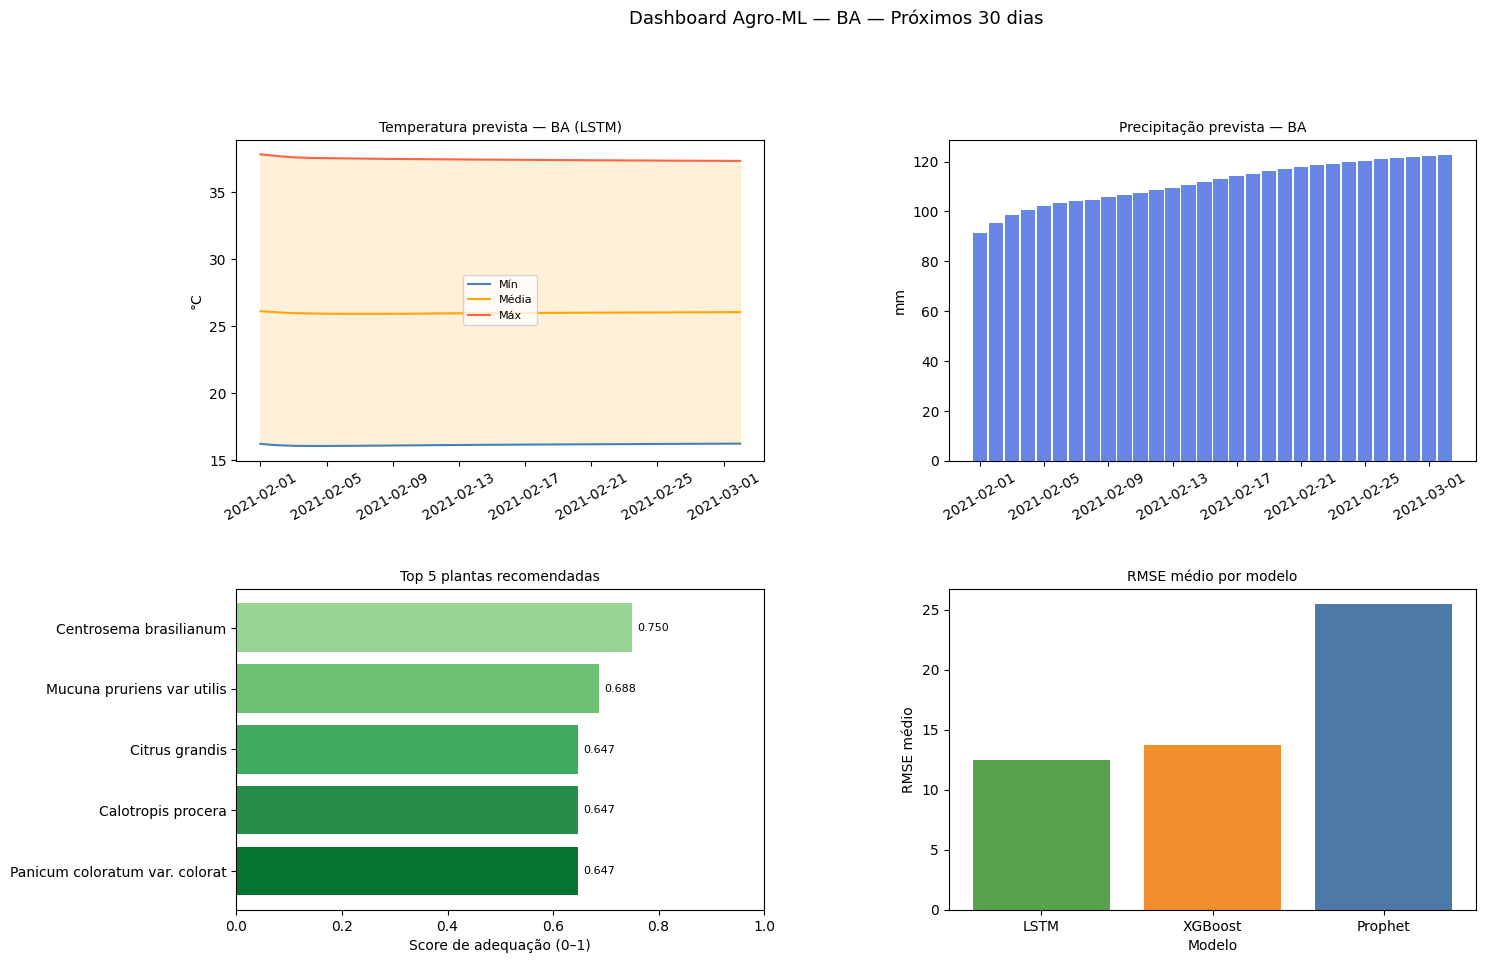

✅ Dashboard salvo em dashboard_agro_ml.png


In [ ]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Painel 1: Previsão temperatura ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(datas_fut, prev_futuro['temp_min'],   label='Mín', color='steelblue', lw=1.5)
ax1.plot(datas_fut, prev_futuro['temp_media'], label='Média', color='orange', lw=1.5)
ax1.plot(datas_fut, prev_futuro['temp_max'],   label='Máx', color='tomato', lw=1.5)
ax1.fill_between(datas_fut, prev_futuro['temp_min'], prev_futuro['temp_max'], alpha=0.15, color='orange')
ax1.set_title(f'Temperatura prevista — {UF_ALVO} ({MELHOR_MODELO})', fontsize=10)
ax1.set_ylabel('°C'); ax1.legend(fontsize=8); ax1.tick_params(axis='x', rotation=30)

# ── Painel 2: Precipitação prevista ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(datas_fut, prev_futuro['precipitacao'], color='royalblue', alpha=0.8, width=0.9)
ax2.set_title(f'Precipitação prevista — {UF_ALVO}', fontsize=10)
ax2.set_ylabel('mm'); ax2.tick_params(axis='x', rotation=30)

# ── Painel 3: Score das top plantas ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
nomes  = top_plantas['ScientificName'].str[:30] if 'ScientificName' in top_plantas.columns \
         else top_plantas.index.astype(str)
scores = top_plantas['score'].values
colors = plt.cm.Greens(np.linspace(0.4, 0.85, len(scores)))[::-1]
bars   = ax3.barh(nomes[::-1], scores[::-1], color=colors)
ax3.set_xlim(0, 1)
ax3.set_xlabel('Score de adequação (0–1)')
ax3.set_title(f'Top {TOP_N_PLANTAS} plantas recomendadas', fontsize=10)
for bar, s in zip(bars, scores[::-1]):
    ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{s:.3f}', va='center', fontsize=8)

# ── Painel 4: Comparação RMSE dos modelos ───────────────────────
ax4 = fig.add_subplot(gs[1, 1])
rmse_media = df_res.groupby('Modelo')['RMSE'].mean().sort_values()
c_map = {'Prophet': '#4e79a7', 'XGBoost': '#f28e2b', 'LSTM': '#59a14f'}
ax4.bar(rmse_media.index, rmse_media.values,
        color=[c_map.get(m, 'gray') for m in rmse_media.index])
ax4.set_title('RMSE médio por modelo', fontsize=10)
ax4.set_ylabel('RMSE médio')
ax4.set_xlabel('Modelo')

plt.suptitle(f'Dashboard Agro-ML — {UF_ALVO} — Próximos {N_DIAS_PREV} dias', fontsize=13, y=1.01)
plt.savefig('dashboard_agro_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard salvo em dashboard_agro_ml.png')

## 10. Exportação dos resultados

In [ ]:
# Previsão climática
df_prev_export = pd.DataFrame({'data': datas_fut})
for var in VARS_CLIMA:
    df_prev_export[var] = prev_futuro[var]
df_prev_export.to_csv('previsao_clima_30d.csv', index=False)

# Top plantas
top_plantas.to_csv('top_plantas_recomendadas.csv', index=False)

# Métricas dos modelos
df_res.to_csv('metricas_modelos.csv', index=False)

print('📁 Arquivos exportados:')
print('   previsao_clima_30d.csv')
print('   top_plantas_recomendadas.csv')
print('   metricas_modelos.csv')
print('   dashboard_agro_ml.png')
print(f'\n🏆 Melhor modelo: {MELHOR_MODELO}')
print(f'🌿 Top planta recomendada: {top_plantas.iloc[0]["ScientificName"] if "ScientificName" in top_plantas.columns else "N/A"}')

📁 Arquivos exportados:
   previsao_clima_30d.csv
   top_plantas_recomendadas.csv
   metricas_modelos.csv
   dashboard_agro_ml.png

🏆 Melhor modelo: LSTM
🌿 Top planta recomendada: Centrosema brasilianum
